In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")

# View first 5 rows
print(df.head())

# Check structure
print(df.info())

# Check basic statistics
print(df.describe())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

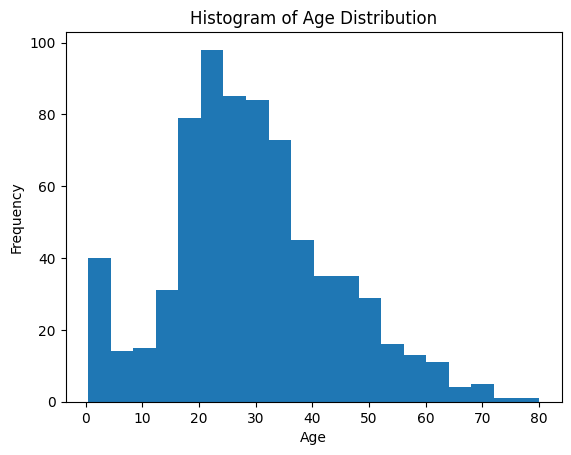

In [2]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram of Age Distribution")
plt.show()

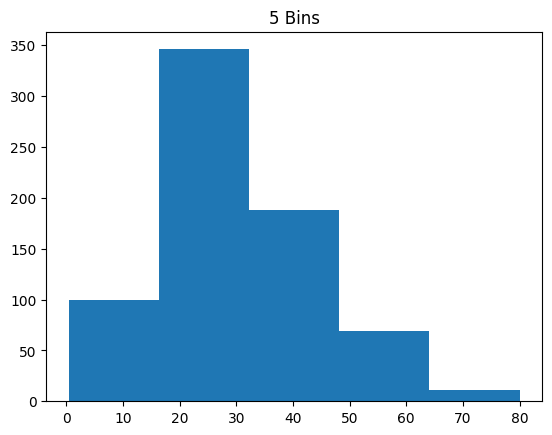

In [3]:
plt.hist(df['Age'], bins=5)
plt.title("5 Bins")
plt.show()

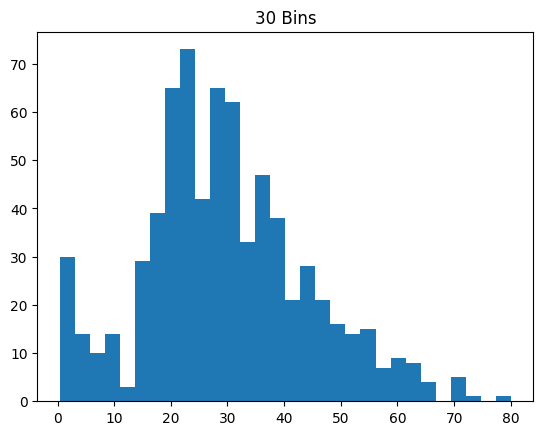

In [4]:
plt.hist(df['Age'], bins=30)
plt.title("30 Bins")
plt.show()

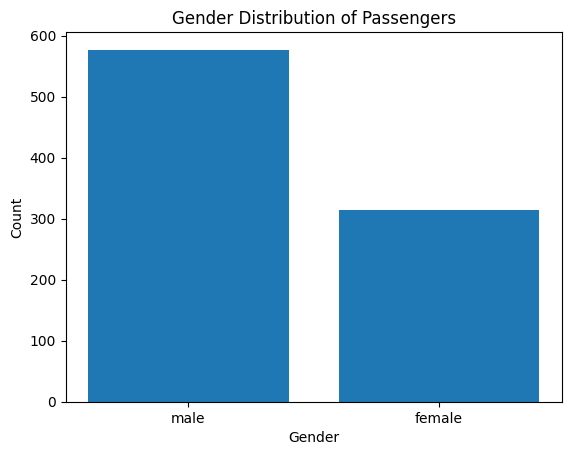

In [5]:
gender_counts = df['Sex'].value_counts()

plt.figure()
plt.bar(gender_counts.index, gender_counts.values)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution of Passengers")
plt.show()


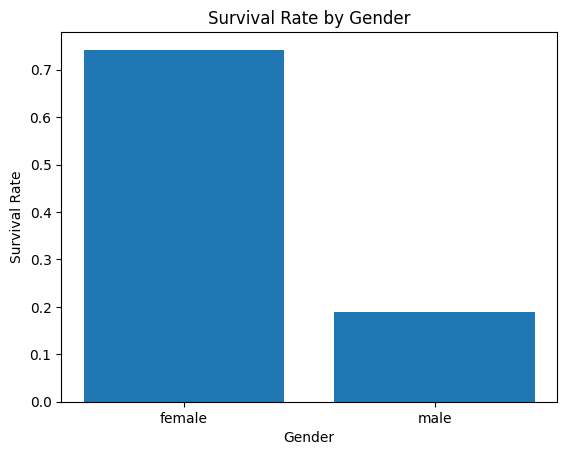

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [6]:
survival_gender = df.groupby('Sex')['Survived'].mean()

plt.figure()
plt.bar(survival_gender.index, survival_gender.values)
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Gender")
plt.show()

print(survival_gender)


In [18]:
# Convert categorical to numeric
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
X = df[['Age', 'Sex', 'Pclass']]
y = df['Survived']
print(X.isnull().sum())


Age       0
Sex       0
Pclass    0
dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (712, 3)
Testing data size: (179, 3)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [15]:
print(X.isnull().sum())

Age       177
Sex       891
Pclass      0
dtype: int64


In [22]:
df['Age'].fillna(df['Age'].median(), inplace=True)

X = df[['Age', 'Sex', 'Pclass']]

print(X.isnull().sum())



Age       0
Sex       0
Pclass    0
dtype: int64


/tmp/ipython-input-2909461155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [24]:
predictions = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))


Accuracy: 0.8100558659217877
Confusion Matrix:
[[91 14]
 [20 54]]


In [26]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coefficients)


  Feature  Coefficient
0     Age    -0.025534
1     Sex     2.474242
2  Pclass    -1.035624


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/Titanic-Dataset.csv")

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin (too many missing values)
df = df.drop(columns=['Cabin'])

# Convert categorical Sex to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Age', 'Sex', 'Pclass', 'Fare', 'SibSp', 'Parch']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


predictions = model.predict(X_test)

print("Improved Model Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))



Improved Model Accuracy: 0.8100558659217877

Confusion Matrix:
[[92 13]
 [21 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

